In [1]:
# # Анализ важности признаков

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import shap

In [2]:
# Загрузка данных
X_train = joblib.load('../data/processed/X_train_scaled.pkl')
X_test = joblib.load('../data/processed/X_test_scaled.pkl')

y_train_reg = joblib.load('../data/processed/y_train_reg.pkl')
y_test_reg = joblib.load('../data/processed/y_test_reg.pkl')
y_train_clf = joblib.load('../data/processed/y_train_clf.pkl')
y_test_clf = joblib.load('../data/processed/y_test_clf.pkl')

feature_names = joblib.load('../data/processed/feature_names.pkl')

# %%
# Загрузка моделей
models = {}
model_paths = {
    'pIC50': '../artifacts/models/best_IC50_regressor.pkl',
    'pCC50': '../artifacts/models/best_CC50_regressor.pkl',
    'log_SI': '../artifacts/models/best_SI_regressor.pkl',
    'IC50_binary': '../artifacts/models/best_IC50_binary.pkl',
    'CC50_binary': '../artifacts/models/best_CC50_binary.pkl',
    'SI_binary': '../artifacts/models/best_SI_binary.pkl',
    'SI_8_binary': '../artifacts/models/best_SI_8_binary.pkl'
}



In [3]:
for name, path in model_paths.items():
    try:
        models[name] = joblib.load(path)
        print(f"Загружена модель: {name}")
    except FileNotFoundError:
        print(f"Модель не найдена: {name}")
    except Exception as e:
        print(f"Ошибка загрузки {name}: {e}")

Загружена модель: pIC50
Загружена модель: pCC50
Загружена модель: log_SI
Загружена модель: IC50_binary
Загружена модель: CC50_binary
Загружена модель: SI_binary
Загружена модель: SI_8_binary


In [4]:
def get_feature_importance(model, X, y, feature_names):
    """
    Получение важности признаков для модели
    
    Parameters:
    -----------
    model : sklearn model
        Обученная модель
    X : array-like
        Признаки (тестовые данные)
    y : array-like
        Целевая переменная (тестовые данные)
    feature_names : list
        Список названий признаков
    
    Returns:
    --------
    dict : Словарь с разными методами оценки важности
    """
    importance = {}
    
    # 1. Коэффициенты для линейных моделей
    if hasattr(model, 'coef_'):
        coef = model.coef_[0] if len(model.coef_.shape) > 1 else model.coef_
        importance['coef'] = pd.Series(np.abs(coef), index=feature_names).sort_values(ascending=False)
    
    # 2. Feature importance для ансамблевых моделей (Random Forest, XGBoost, Gradient Boosting)
    if hasattr(model, 'feature_importances_'):
        importance['rf'] = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
    
    # 3. Permutation importance - универсальный метод для любых моделей
    try:
        perm = permutation_importance(
            model, 
            X, 
            y, 
            n_repeats=10, 
            random_state=42,
            n_jobs=-1  # параллельные вычисления
        )
        importance['permutation'] = pd.Series(
            perm.importances_mean, 
            index=feature_names
        ).sort_values(ascending=False)
    except Exception as e:
        print(f"Permutation importance не вычислена: {e}")
    
    return importance

In [5]:
# Анализ регрессионных моделей
reg_targets = ['pIC50', 'pCC50', 'log_SI']
reg_importance = {}

for target in reg_targets:
    if target in models:
        y = y_test_reg[target].values
        reg_importance[target] = get_feature_importance(models[target], X_test, y, feature_names)

In [6]:
len(reg_importance)

3

In [7]:
# Анализ классификационных моделей
clf_targets = ['IC50_binary', 'CC50_binary', 'SI_binary', 'SI_8_binary']
clf_importance = {}

for target in clf_targets:
    if target in models:
        y = y_test_clf[target].values
        clf_importance[target] = get_feature_importance(models[target], X_test, y, feature_names)

In [8]:
len(clf_importance)

4

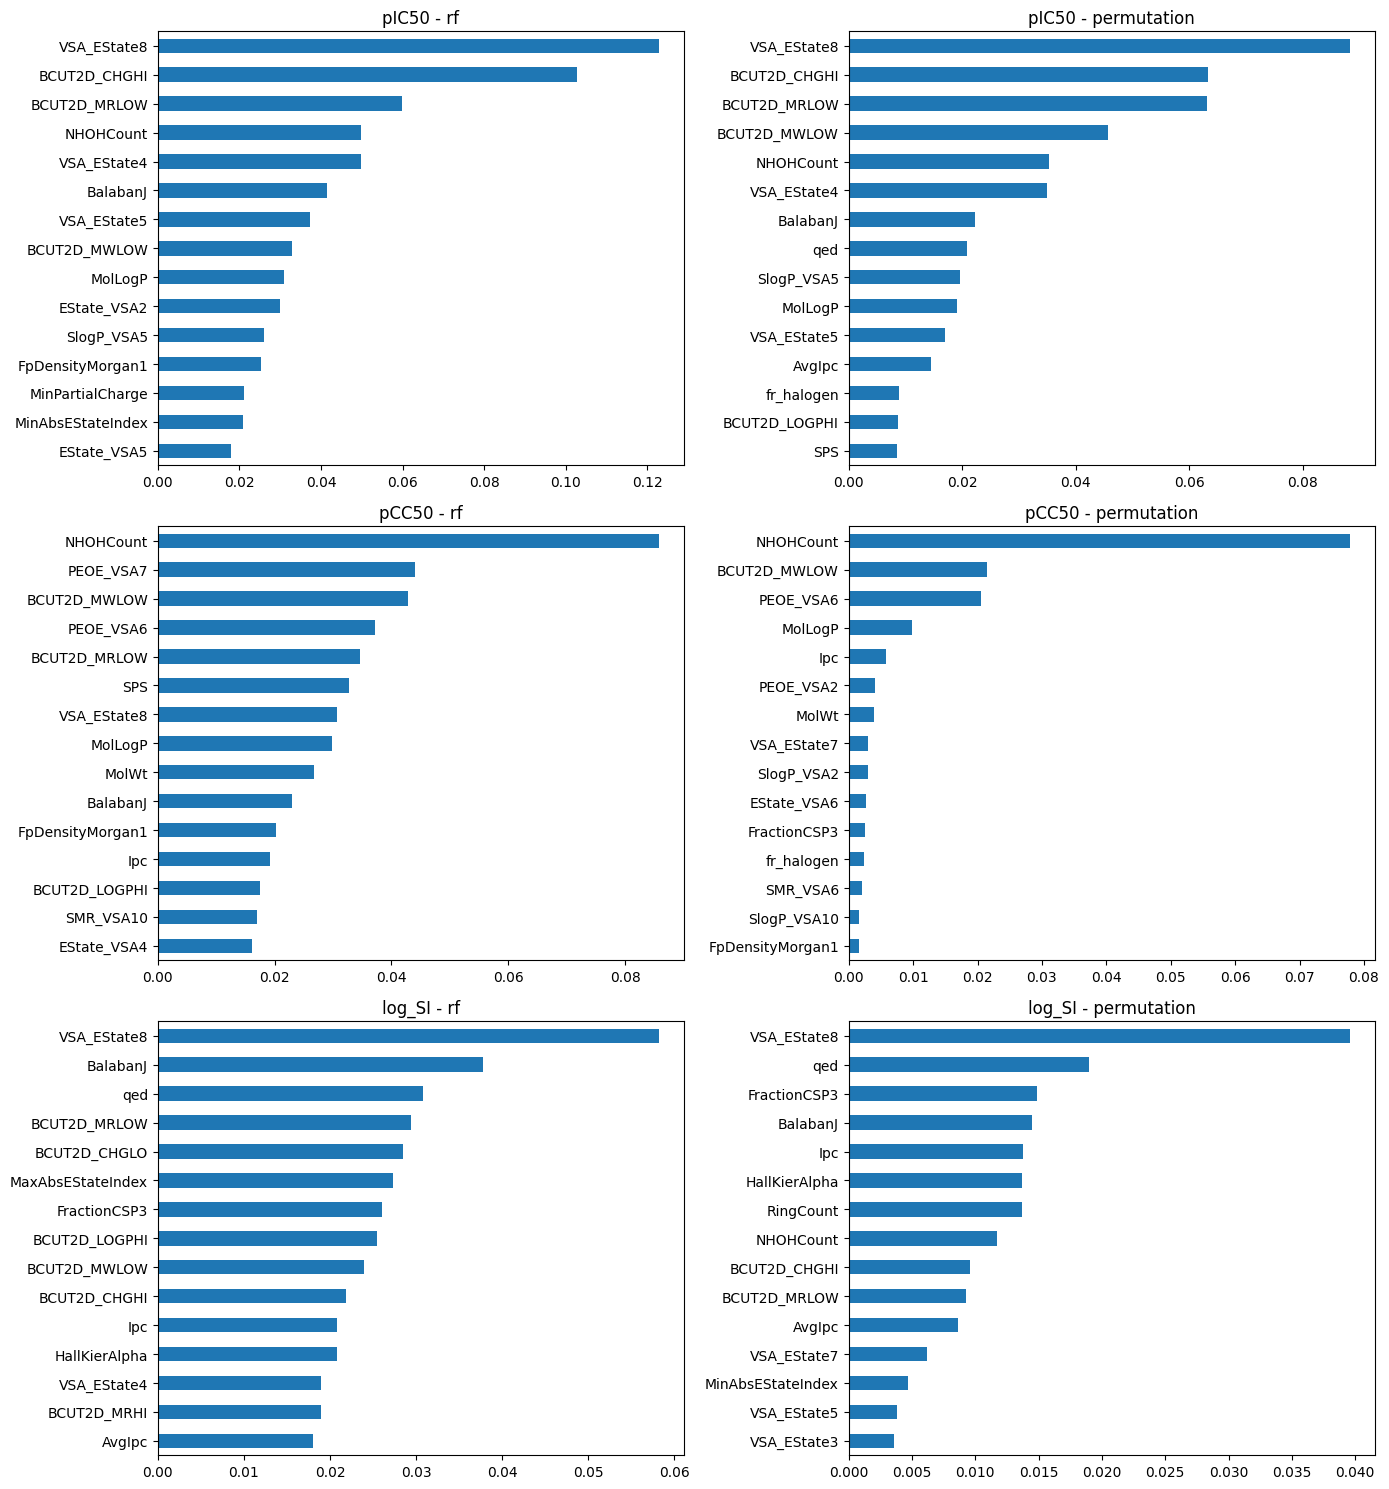

In [9]:
# Визуализация важности признаков для регрессии
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()
idx = 0

for target, imp_dict in reg_importance.items():
    for method, series in imp_dict.items():
        if idx < len(axes):
            series.head(15).plot(kind='barh', ax=axes[idx])
            axes[idx].set_title(f'{target} - {method}')
            axes[idx].invert_yaxis()
            idx += 1

for i in range(idx, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
#plt.savefig('../report/figures/regression_importance.png', dpi=300, bbox_inches='tight')
plt.show()

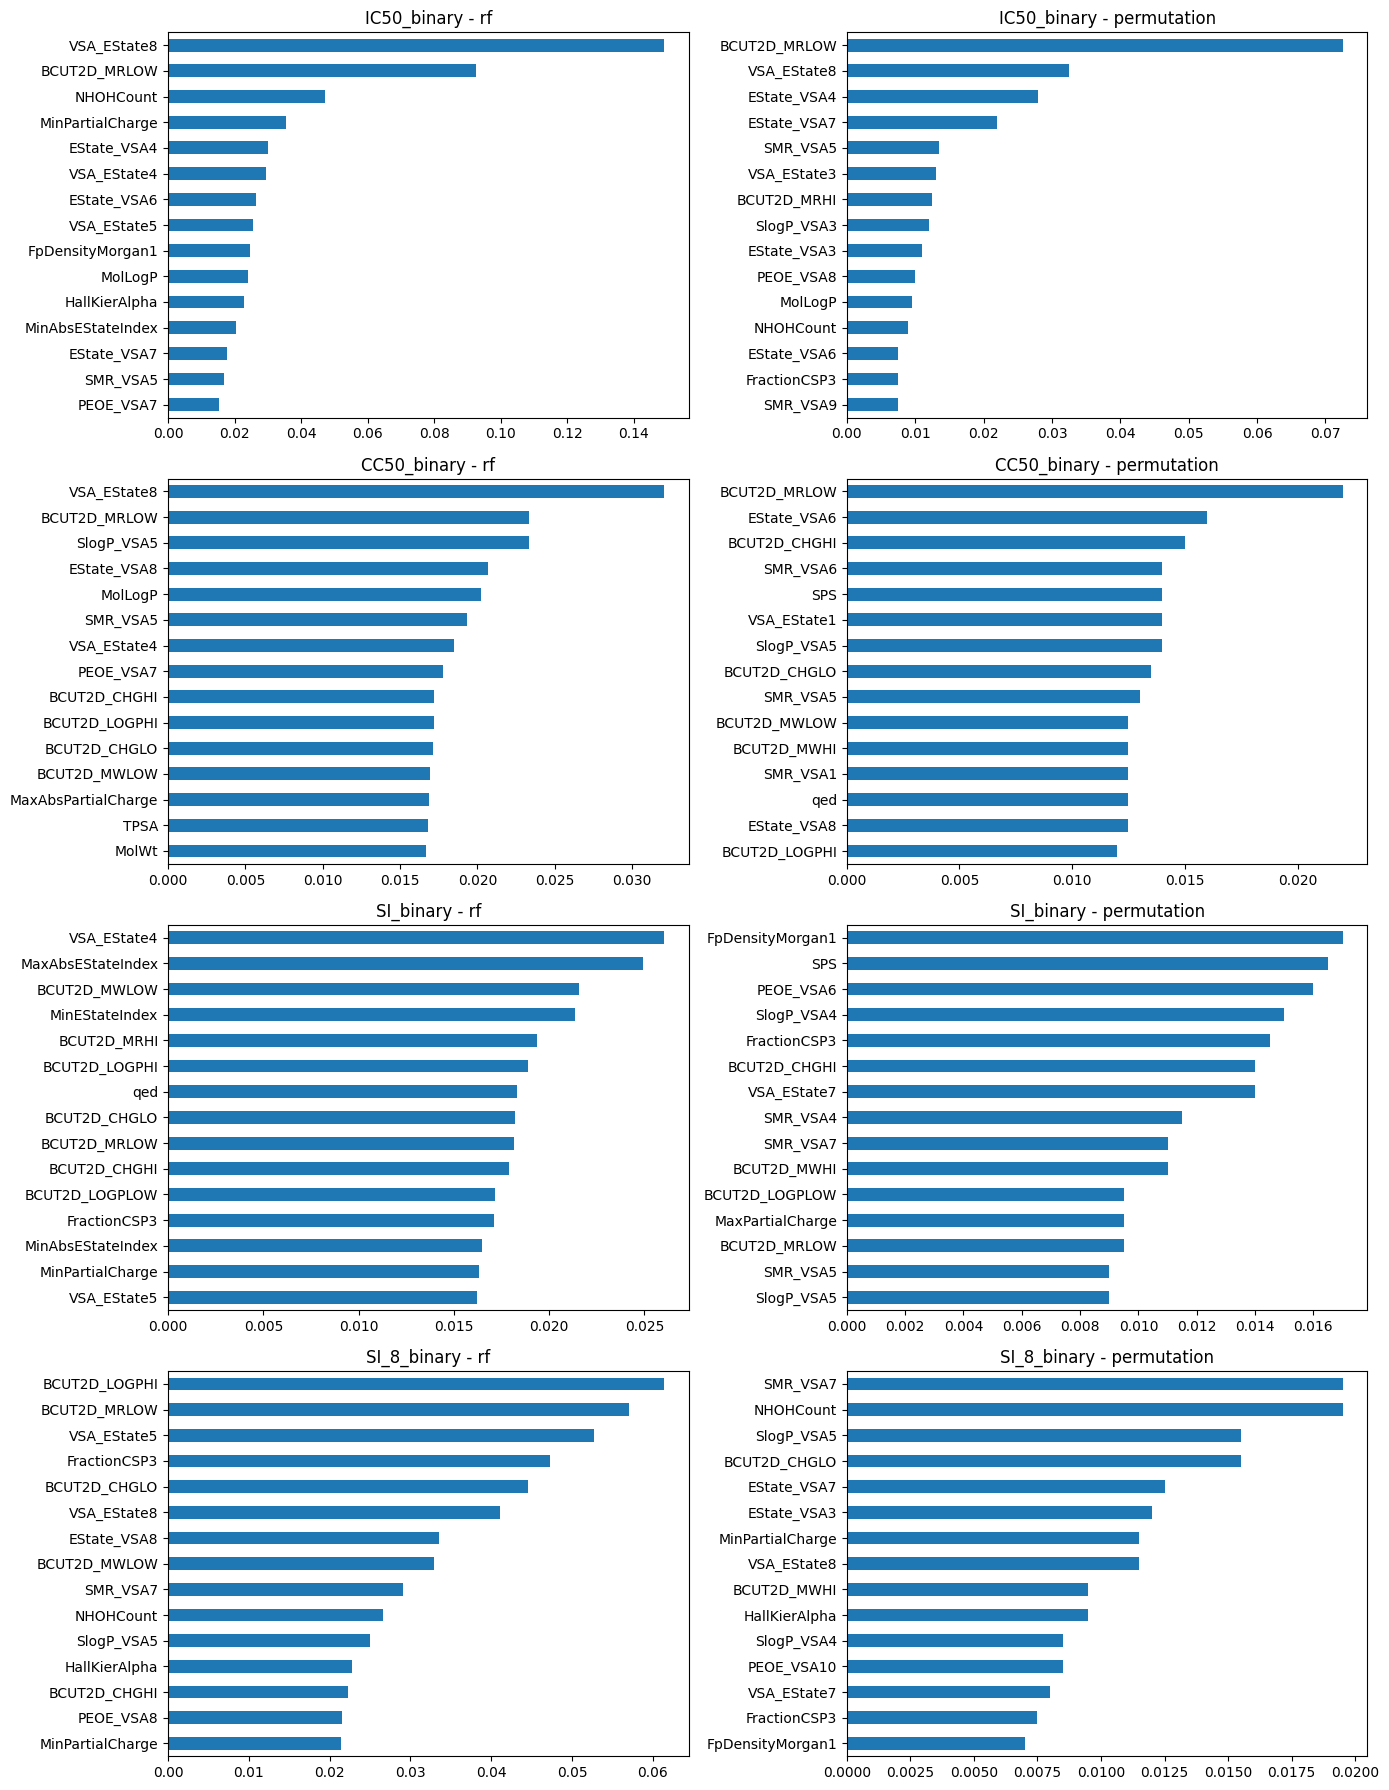

In [10]:
#Визуализация важности признаков для классификации
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()
idx = 0

for target, imp_dict in clf_importance.items():
    for method, series in imp_dict.items():
        if idx < len(axes):
            series.head(15).plot(kind='barh', ax=axes[idx])
            axes[idx].set_title(f'{target} - {method}')
            axes[idx].invert_yaxis()
            idx += 1

for i in range(idx, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
#plt.savefig('../report/figures/classification_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Сводная таблица топ-10 важных признаков
def create_summary(importance_dict, top_n=10):
    summary = {}
    for target, imp_methods in importance_dict.items():
        if 'rf' in imp_methods:
            summary[target] = imp_methods['rf'].head(top_n)
        elif 'coef' in imp_methods:
            summary[target] = imp_methods['coef'].head(top_n)
        elif 'permutation' in imp_methods:
            summary[target] = imp_methods['permutation'].head(top_n)
    return summary

reg_summary = create_summary(reg_importance)
clf_summary = create_summary(clf_importance)

In [12]:
reg_summary['pIC50']

VSA_EState8     0.122779
BCUT2D_CHGHI    0.102794
BCUT2D_MRLOW    0.059767
NHOHCount       0.049791
VSA_EState4     0.049746
BalabanJ        0.041380
VSA_EState5     0.037388
BCUT2D_MWLOW    0.032816
MolLogP         0.030886
EState_VSA2     0.029859
dtype: float64

In [13]:
reg_summary['pCC50']

NHOHCount       0.085761
PEOE_VSA7       0.044007
BCUT2D_MWLOW    0.042865
PEOE_VSA6       0.037173
BCUT2D_MRLOW    0.034591
SPS             0.032694
VSA_EState8     0.030598
MolLogP         0.029740
MolWt           0.026759
BalabanJ        0.022923
dtype: float64

In [14]:
reg_summary['log_SI']

VSA_EState8          0.058217
BalabanJ             0.037789
qed                  0.030836
BCUT2D_MRLOW         0.029468
BCUT2D_CHGLO         0.028531
MaxAbsEStateIndex    0.027328
FractionCSP3         0.026085
BCUT2D_LOGPHI        0.025415
BCUT2D_MWLOW         0.023988
BCUT2D_CHGHI         0.021856
dtype: float64

In [15]:
clf_summary['IC50_binary']

VSA_EState8         0.149072
BCUT2D_MRLOW        0.092633
NHOHCount           0.047272
MinPartialCharge    0.035342
EState_VSA4         0.030116
VSA_EState4         0.029490
EState_VSA6         0.026462
VSA_EState5         0.025647
FpDensityMorgan1    0.024685
MolLogP             0.024166
dtype: float64

In [16]:
clf_summary['CC50_binary']

VSA_EState8      0.032056
BCUT2D_MRLOW     0.023341
SlogP_VSA5       0.023341
EState_VSA8      0.020676
MolLogP          0.020246
SMR_VSA5         0.019306
VSA_EState4      0.018515
PEOE_VSA7        0.017764
BCUT2D_CHGHI     0.017217
BCUT2D_LOGPHI    0.017161
dtype: float64

In [17]:
clf_summary['SI_binary']

VSA_EState4          0.026022
MaxAbsEStateIndex    0.024903
BCUT2D_MWLOW         0.021542
MinEStateIndex       0.021349
BCUT2D_MRHI          0.019340
BCUT2D_LOGPHI        0.018912
qed                  0.018306
BCUT2D_CHGLO         0.018187
BCUT2D_MRLOW         0.018164
BCUT2D_CHGHI         0.017877
dtype: float64

In [18]:
clf_summary['SI_8_binary']

BCUT2D_LOGPHI    0.061367
BCUT2D_MRLOW     0.057012
VSA_EState5      0.052720
FractionCSP3     0.047288
BCUT2D_CHGLO     0.044533
VSA_EState8      0.041052
EState_VSA8      0.033558
BCUT2D_MWLOW     0.032889
SMR_VSA7         0.029100
NHOHCount        0.026637
dtype: float64

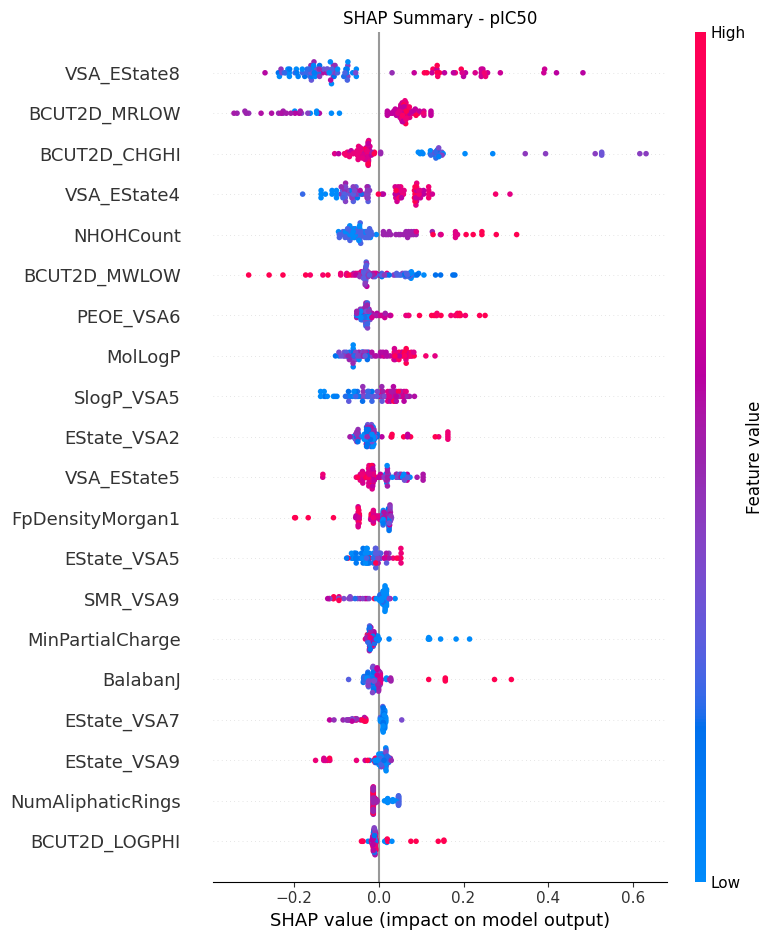

In [19]:
# SHAP анализ
model = models.get('pIC50')
if model and hasattr(model, 'feature_importances_'):

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test[:100])
    
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test[:100], feature_names=feature_names, show=False)
    plt.title('SHAP Summary - pIC50')
    plt.tight_layout()
    #plt.savefig('../report/figures/shap_pIC50.png', dpi=300, bbox_inches='tight')
    plt.show()


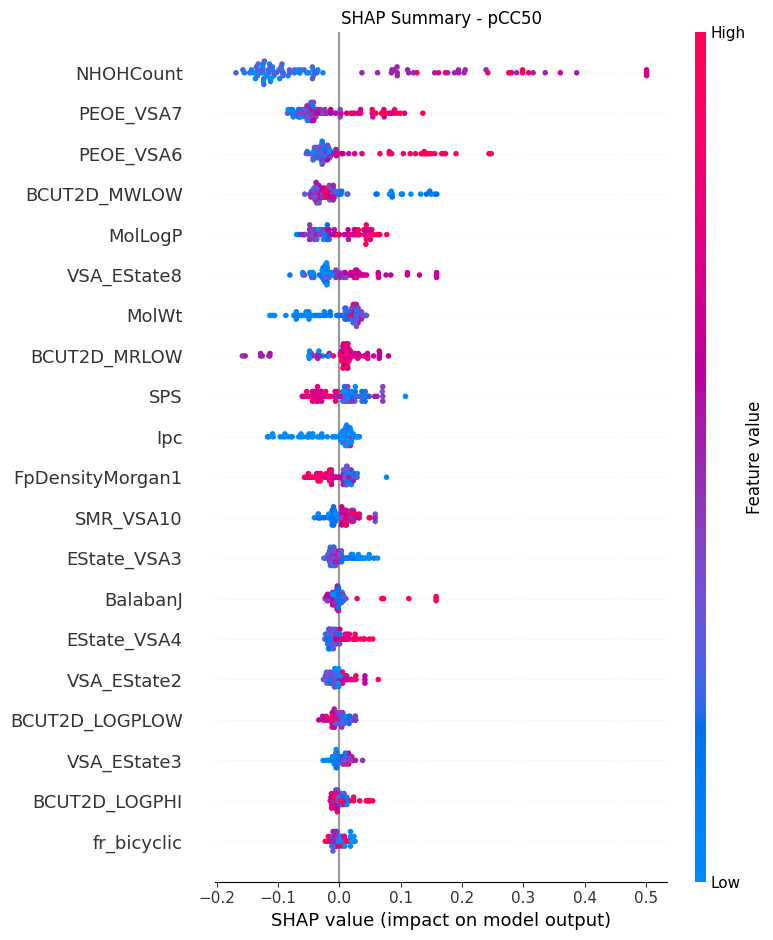

In [20]:
# SHAP анализ
model = models.get('pCC50')
if model and hasattr(model, 'feature_importances_'):

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test[:100])
    
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test[:100], feature_names=feature_names, show=False)
    plt.title('SHAP Summary - pСC50')
    plt.tight_layout()
    #plt.savefig('../report/figures/shap_pIC50.png', dpi=300, bbox_inches='tight')
    plt.show()


In [21]:
# Сохранение результатов
def save_results(importance_dict, filename):
    results = []
    for target, methods in importance_dict.items():
        for method, series in methods.items():
            for feat, imp in series.items():
                results.append({'target': target, 'method': method, 'feature': feat, 'importance': imp})
    pd.DataFrame(results).to_csv(filename, index=False)

#save_results(reg_importance, '../artifacts/results/regression_importance.csv')
#save_results(clf_importance, '../artifacts/results/classification_importance.csv')

In [22]:
# Вывод наиболее важных признаков
from collections import Counter

all_top_features = []
for features in reg_summary.values():
    all_top_features.extend(features.head(5).index)
for features in clf_summary.values():
    all_top_features.extend(features.head(5).index)

for feature, count in Counter(all_top_features).most_common(10):
    print(f"  {feature}: {count}")

  BCUT2D_MRLOW: 6
  VSA_EState8: 4
  NHOHCount: 3
  VSA_EState4: 2
  BCUT2D_MWLOW: 2
  BCUT2D_CHGLO: 2
  BCUT2D_CHGHI: 1
  PEOE_VSA7: 1
  PEOE_VSA6: 1
  BalabanJ: 1


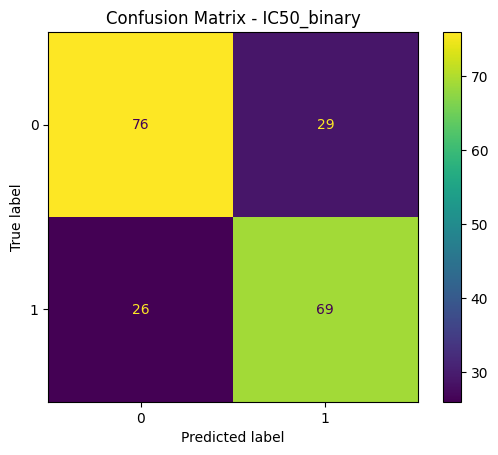

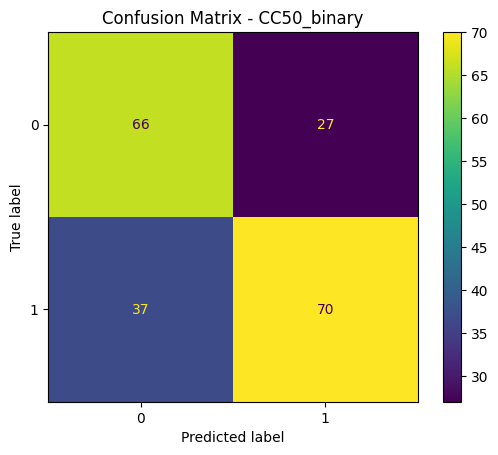

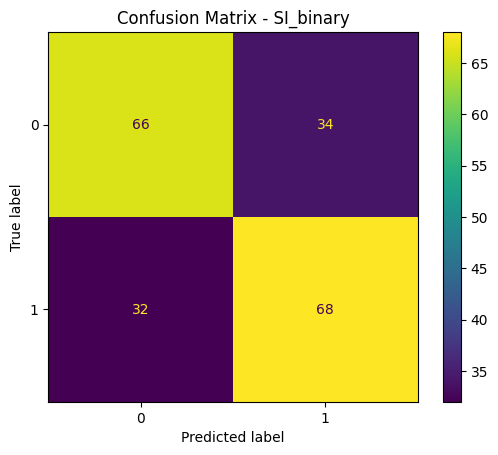

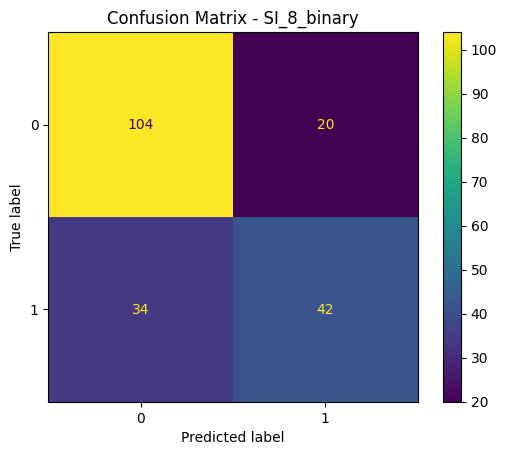

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for task in ['IC50_binary', 'CC50_binary', 'SI_binary', 'SI_8_binary']:
    if task in models:
        y_pred = models[task].predict(X_test)
        cm = confusion_matrix(y_test_clf[task], y_pred)
        ConfusionMatrixDisplay(cm).plot()
        plt.title(f'Confusion Matrix - {task}')
        plt.show()